Matching GeomLoss and OTT-JAX
=============================

**When to use:** you move code from GeomLoss or OTT-JAX, or compare numbers with them, and need the settings
under which flash-sinkhorn solves the same problem.

**What you will see:** on 100,000 points, what goes wrong when the cost convention is left at its default, the
half cost as an exact rescaling of the full cost, the symmetric (GeomLoss-style) and alternating (OTT-style)
backends converging to the same plan, and the conversion between the two libraries' potentials.

Source: [plot_conventions.py](plot_conventions.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/choosing_parameters/plot_conventions.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/choosing_parameters/plot_conventions.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss
from flash_sinkhorn.hvp import geomloss_to_ott_potentials

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import (ARROW, SOURCE, TARGET, arrows, cloud, dense_size, fit_limits, images_dir,  # noqa: E402
                       require_cuda, save, subsample, table, timed)

device = require_cuda()
torch.manual_seed(0)
n = m = 100_000
x = 0.25 * torch.randn(n, 2, device=device) + torch.tensor([-0.8, 0.0], device=device)
theta = 1.2 + 2.6 * torch.rand(m, device=device)
y = torch.stack([0.6 + 0.8 * torch.cos(theta), 0.8 * torch.sin(theta)], dim=1)
y = y + 0.04 * torch.randn(m, 2, device=device)
a = torch.full((n,), 1.0 / n, device=device)
b = torch.full((m,), 1.0 / m, device=device)
print(dense_size(n, m))

GeomLoss
--------
``SamplesLoss`` follows GeomLoss's calling convention with two different defaults: the cost is the full
|x - y|^2 (GeomLoss's ``p=2`` uses |x - y|^2 / 2) and ``debias=False`` (GeomLoss: ``True``). So

    geomloss.SamplesLoss("sinkhorn", p=2, blur=blur, scaling=scaling)
    SamplesLoss(blur=blur, scaling=scaling, half_cost=True, debias=True)

describe the same problem; eps = blur^2 and ``reach=r`` means a marginal penalty of strength r^2 in both.
Left at the full cost, the same blur describes another problem: the cost is doubled, so the gradient is
roughly twice as large, and a GeomLoss-style step x - grad / a overshoots the target (left panel).

In [ ]:
blur = 0.05


def displacement(half_cost):
    """-grad_x S_eps / a for one cost convention."""
    loss = SamplesLoss(blur=blur, half_cost=half_cost, debias=True, backend="symmetric", autotune=False)
    z = x.clone().requires_grad_(True)
    grad, = torch.autograd.grad(loss(a, z, b, y), z)
    return -grad / a[:, None]


v_half = timed("gradient, half_cost=True", lambda: displacement(True))
v_full = timed("gradient, half_cost=False", lambda: displacement(False))
ratio = (v_full.norm(dim=1).mean() / v_half.norm(dim=1).mean()).item()
cosine = torch.nn.functional.cosine_similarity(v_full.flatten(), v_half.flatten(), dim=0).item()
print(f"full cost against half cost: arrows {ratio:.2f} times as long on average, cosine {cosine:.3f}")

The half cost is a rescaling: the entropic problem with cost C / 2 at eps is half the problem with cost C at
2 eps, iterate by iterate. Run with a schedule and with the same schedule doubled, the potentials agree after
halving whether or not the solve has converged; with each run's own automatic schedule they agree only once
both have converged, and then only up to an additive constant.

In [ ]:
schedule = [max(blur**2, 4.0 * 0.25**k) for k in range(7)] + [blur**2] * 20
f_half, _ = SamplesLoss(eps_list=schedule, half_cost=True, debias=False, backend="symmetric", potentials=True,
                        autotune=False)(a, x, b, y)
f_full, _ = SamplesLoss(eps_list=[2 * e for e in schedule], half_cost=False, debias=False, backend="symmetric",
                        potentials=True, autotune=False)(a, x, b, y)
print(f"half cost against the full cost with the schedule doubled: max |f_half - f_full / 2| = "
      f"{(f_half - f_full / 2).abs().max().item():.2e}, max |f_half| = {f_half.abs().max().item():.2f}")

OTT-JAX
-------
OTT-JAX alternates the two potential updates at a fixed eps. ``backend="alternating"`` with
``use_epsilon_scaling=False``, ``eps`` and ``n_iters`` runs that scheme. OTT stores the potentials
f_hat = f + eps log a, g_hat = g + eps log b, with P = exp((f_hat + g_hat - C) / eps);
``geomloss_to_ott_potentials`` converts. For unbalanced problems, OTT's tau = rho / (rho + eps) with
rho = reach^2.

Both backends solve the same problem with different update orders. Before convergence their iterates differ;
converged, they give the same plan, and the potentials agree up to an additive constant, a free gauge of
balanced OT (f + c and g - c give the same plan). The right panel shows the difference shrinking as the runs
get longer. For each n, the alternating run makes n updates at the target eps; the symmetric run anneals from
eps = 4 down to the target eps, makes n more updates there, and ends with a final extrapolation.

In [ ]:
eps = 0.04  # blur 0.2
iterations = [10, 25, 50, 100, 200]
gaps, constants = [], []
for n_iters in iterations:
    symmetric = SamplesLoss(eps_list=[max(eps, 4.0 * 0.25**k) for k in range(5)] + [eps] * n_iters,
                            half_cost=True, debias=False, backend="symmetric", potentials=True, autotune=False)
    alternating = SamplesLoss(eps=eps, n_iters=n_iters, use_epsilon_scaling=False, half_cost=True, debias=False,
                              backend="alternating", potentials=True, autotune=False)
    f_sym, g_sym = symmetric(a, x, b, y)
    f_alt, g_alt = alternating(a, x, b, y)
    gauge = (f_sym - f_alt).mean()
    gaps.append(max((f_sym - f_alt - gauge).abs().max().item(), (g_sym - g_alt + gauge).abs().max().item()))
    constants.append(gauge.item())
    print(f"n = {n_iters:3d}: additive constant {gauge.item():+.4f}, "
          f"max difference after removing it {gaps[-1]:.1e}")
f_ott, g_ott = geomloss_to_ott_potentials(f_sym, g_sym, a, b, eps=eps)
print(f"OTT potentials: f_hat - f = eps log a = {(f_ott - f_sym).mean().item():+.4f} for every point here")

Figure
------
Left: arrows -grad S_eps / a for 100 random points, with the half cost (green, GeomLoss's p=2) and the full
cost (red). Right: the additive constant between the two backends' potentials and their largest difference
once it is removed.

In [ ]:
idx = subsample(n, 100, device=device)
fig, (ax_arrows, ax_gap) = plt.subplots(1, 2, figsize=(10.0, 4.2))
cloud(ax_arrows, y, TARGET)
cloud(ax_arrows, x, SOURCE)
arrows(ax_arrows, x[idx], v_full[idx], color=(0.8, 0.25, 0.25))
arrows(ax_arrows, x[idx], v_half[idx], color=ARROW)
fit_limits(ax_arrows, x, y, x[idx] + v_full[idx])
ax_arrows.set_aspect("equal")
ax_arrows.set_xticks([])
ax_arrows.set_yticks([])
ax_arrows.set_title("half_cost=True (green) vs False (red)")
table(ax_gap, ["n", "additive constant", "max difference"],
      [[str(it), f"{c:+.4f}", f"{gap:.1e}"] for it, c, gap in zip(iterations, constants, gaps)],
      title="symmetric vs alternating")
fig.tight_layout()
save(fig, images_dir(__file__), "conventions")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/choosing_parameters/images/conventions.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

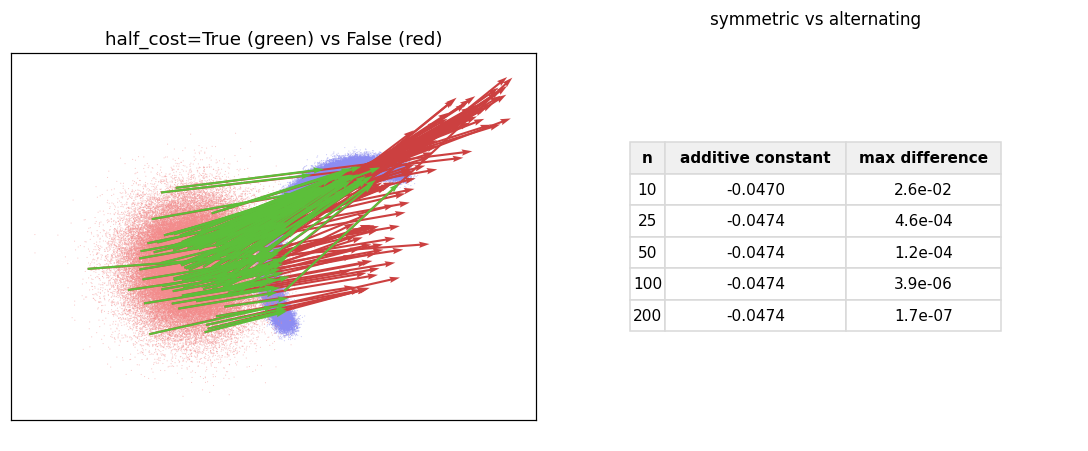